# EuroSAT Optical ↔ Multispectral Hybrid Retrieval Training

This notebook uses the combined RGB + multispectral + SAR TFRecords but trains only:

- Optical RGB
- 13-band multispectral

It saves:

- optical and multispectral encoders
- classification reports for both modalities
- training-history subplots
- retrieval metrics for:
  - Optical → Optical
  - Multispectral → Multispectral
  - Optical → Multispectral
  - Multispectral → Optical
- Precision@K, Recall@K and F1@K
- random retrieval examples for all four directions
- inference-ready files
- complete result-directory upload to Kaggle


In [1]:
!pip install -q -U kagglehub scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 17.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


## 1. Imports and configuration

In [2]:
import json
import os
import random
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from kaggle_secrets import UserSecretsClient
from sklearn.metrics import classification_report
from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.keras.mixed_precision.set_global_policy("float32")
tf.config.optimizer.set_jit(False)

TFRECORD_HANDLE = "glitchr/eurosat-rgb-ms-sar-paired-tfrecords"

OUT_DIR = Path("/kaggle/working/eurodata_optical_multispectral_hybrid_results")
MODEL_DIR = OUT_DIR / "models"
REPORT_DIR = OUT_DIR / "reports"
PLOT_DIR = OUT_DIR / "plots"
EMB_DIR = OUT_DIR / "embeddings"

for directory in [OUT_DIR, MODEL_DIR, REPORT_DIR, PLOT_DIR, EMB_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 64
RGB_CHANNELS = 3
MS_CHANNELS = 13
NUM_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 100
EMBED_DIM = 256
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
TRIPLET_MARGIN = 0.2
TEMPERATURE = 1.0

K_LIST = [1, 5, 10, 20, 50]

CLASS_NAMES = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake",
]

print("TensorFlow:", tf.__version__)
print("Output directory:", OUT_DIR)

2026-06-25 09:11:36.375544: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782378696.563492      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782378696.621243      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782378697.075165      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782378697.075214      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782378697.075217      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
Output directory: /kaggle/working/eurodata_optical_multispectral_hybrid_results


## 2. Download and load paired TFRecords

In [3]:
downloaded_dir = Path(kagglehub.dataset_download(TFRECORD_HANDLE))

candidate_roots = [downloaded_dir]
candidate_roots.extend(
    path.parent
    for path in downloaded_dir.rglob("manifest.json")
)

TFREC_DIR = next(
    root
    for root in candidate_roots
    if (root / "manifest.json").exists()
)

manifest = json.loads(
    (TFREC_DIR / "manifest.json").read_text()
)

MS_MEAN = np.asarray(
    manifest["ms_normalization"]["mean"],
    dtype=np.float32,
)

MS_STD = np.asarray(
    manifest["ms_normalization"]["std"],
    dtype=np.float32,
)

MS_MEAN_T = tf.constant(
    MS_MEAN.reshape(1, 1, -1),
    dtype=tf.float32,
)

MS_STD_T = tf.constant(
    MS_STD.reshape(1, 1, -1),
    dtype=tf.float32,
)

train_df = pd.read_csv(TFREC_DIR / "train_metadata.csv")
validation_df = pd.read_csv(TFREC_DIR / "validation_metadata.csv")
test_df = pd.read_csv(TFREC_DIR / "test_metadata.csv")

print("TFRecord directory:", TFREC_DIR)
print("Train examples:", len(train_df))
print("Validation examples:", len(validation_df))
print("Test examples:", len(test_df))

I0000 00:00:1782378711.236681      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


TFRecord directory: /kaggle/input/datasets/glitchr/eurosat-rgb-ms-sar-paired-tfrecords
Train examples: 18900
Validation examples: 4050
Test examples: 4050


In [4]:
FEATURE_SPEC = {
    "rgb_raw": tf.io.FixedLenFeature([], tf.string),
    "ms_raw": tf.io.FixedLenFeature([], tf.string),
    "sar_raw": tf.io.FixedLenFeature([], tf.string),
    "target": tf.io.FixedLenFeature([], tf.int64),
    "file_id": tf.io.FixedLenFeature([], tf.string),
    "label": tf.io.FixedLenFeature([], tf.string),
}

def resolve_shard_paths(split):
    shard_names = manifest["splits"][split]["shards"]
    paths = []

    for shard_name in shard_names:
        shard_path = TFREC_DIR / shard_name

        if not shard_path.exists() and shard_name.endswith(".gz"):
            shard_path = TFREC_DIR / shard_name.removesuffix(".gz")

        if not shard_path.exists() and shard_name.endswith(".tfrecord"):
            shard_path = TFREC_DIR / f"{shard_name}.gz"

        if not shard_path.exists():
            raise FileNotFoundError(shard_name)

        paths.append(str(shard_path))

    compression_type = (
        "GZIP"
        if all(path.endswith(".gz") for path in paths)
        else ""
    )

    return paths, compression_type

def decode_record(serialized):
    item = tf.io.parse_single_example(
        serialized,
        FEATURE_SPEC,
    )

    rgb = tf.io.parse_tensor(
        item["rgb_raw"],
        out_type=tf.uint8,
    )

    ms = tf.io.parse_tensor(
        item["ms_raw"],
        out_type=tf.float16,
    )

    rgb = tf.ensure_shape(
        rgb,
        [IMAGE_SIZE, IMAGE_SIZE, RGB_CHANNELS],
    )

    ms = tf.ensure_shape(
        ms,
        [IMAGE_SIZE, IMAGE_SIZE, MS_CHANNELS],
    )

    rgb = tf.cast(rgb, tf.float32) / 255.0

    ms = tf.cast(ms, tf.float32)
    ms = (ms - MS_MEAN_T) / tf.maximum(MS_STD_T, 1e-3)
    ms = tf.clip_by_value(ms, -5.0, 5.0)

    tf.debugging.assert_all_finite(
        rgb,
        "RGB tensor contains NaN or infinity.",
    )

    tf.debugging.assert_all_finite(
        ms,
        "Multispectral tensor contains NaN or infinity.",
    )

    target = tf.cast(item["target"], tf.int32)

    return {
        "rgb": rgb,
        "ms": ms,
        "file_id": item["file_id"],
        "label": item["label"],
    }, target

In [5]:
def paired_augment(inputs, target):
    rgb = inputs["rgb"]
    ms = inputs["ms"]

    seed = tf.random.uniform(
        [2],
        maxval=2**31 - 1,
        dtype=tf.int32,
    )

    rgb = tf.image.stateless_random_flip_left_right(rgb, seed)
    ms = tf.image.stateless_random_flip_left_right(ms, seed)

    second_seed = seed + tf.constant([17, 29], dtype=tf.int32)

    rgb = tf.image.stateless_random_flip_up_down(rgb, second_seed)
    ms = tf.image.stateless_random_flip_up_down(ms, second_seed)

    rotation_k = tf.random.stateless_uniform(
        [],
        seed + tf.constant([31, 43]),
        minval=0,
        maxval=4,
        dtype=tf.int32,
    )

    rgb = tf.image.rot90(rgb, rotation_k)
    ms = tf.image.rot90(ms, rotation_k)

    rgb = tf.image.stateless_random_brightness(
        rgb,
        max_delta=0.05,
        seed=seed + 59,
    )

    rgb = tf.image.stateless_random_contrast(
        rgb,
        lower=0.9,
        upper=1.1,
        seed=seed + 71,
    )

    rgb = tf.clip_by_value(rgb, 0.0, 1.0)

    ms_scale = tf.random.stateless_uniform(
        [1, 1, MS_CHANNELS],
        seed=seed + 83,
        minval=0.97,
        maxval=1.03,
    )

    ms = tf.clip_by_value(ms * ms_scale, -5.0, 5.0)

    return {
        "rgb": rgb,
        "ms": ms,
        "file_id": inputs["file_id"],
        "label": inputs["label"],
    }, target


def make_dataset(split, training=False, include_metadata=False):
    shard_paths, compression_type = resolve_shard_paths(split)

    dataset = tf.data.TFRecordDataset(
        shard_paths,
        compression_type=compression_type,
        num_parallel_reads=tf.data.AUTOTUNE,
    )

    dataset = dataset.map(
        decode_record,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=not training,
    )

    if training:
        dataset = dataset.shuffle(
            min(int(manifest["splits"][split]["examples"]), 8192),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

        dataset = dataset.map(
            paired_augment,
            num_parallel_calls=tf.data.AUTOTUNE,
            deterministic=False,
        )

    if not include_metadata:
        dataset = dataset.map(
            lambda inputs, target: (
                {
                    "rgb": inputs["rgb"],
                    "ms": inputs["ms"],
                },
                target,
            ),
            num_parallel_calls=tf.data.AUTOTUNE,
            deterministic=not training,
        )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=training,
    )

    return dataset.prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset(
    "train",
    training=True,
)

validation_ds = make_dataset("validation")

test_ds = make_dataset("test")

test_metadata_ds = make_dataset(
    "test",
    include_metadata=True,
)

sample_inputs, sample_targets = next(iter(train_ds))

print("RGB batch:", sample_inputs["rgb"].shape)
print("MS batch:", sample_inputs["ms"].shape)
print("Targets:", sample_targets.shape)

RGB batch: (64, 64, 64, 3)
MS batch: (64, 64, 64, 13)
Targets: (64,)


## 3. Hybrid encoder

In [6]:
layers = tf.keras.layers


@tf.keras.utils.register_keras_serializable(package="EuroData")
class SqueezeExcitation(layers.Layer):
    def __init__(self, reduction=16, **kwargs):
        super().__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        channels = int(input_shape[-1])
        reduced_channels = max(channels // self.reduction, 8)

        self.reduce_conv = layers.Conv2D(
            reduced_channels,
            kernel_size=1,
            activation="relu",
        )

        self.expand_conv = layers.Conv2D(
            channels,
            kernel_size=1,
            activation="sigmoid",
        )

        super().build(input_shape)

    def call(self, inputs):
        weights = tf.reduce_mean(
            inputs,
            axis=[1, 2],
            keepdims=True,
        )

        weights = self.reduce_conv(weights)
        weights = self.expand_conv(weights)

        return inputs * weights


@tf.keras.utils.register_keras_serializable(package="EuroData")
class CoordinateAttention(layers.Layer):
    def __init__(self, reduction=8, **kwargs):
        super().__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        channels = int(input_shape[-1])
        reduced_channels = max(channels // self.reduction, 8)

        self.shared_conv = layers.Conv2D(
            reduced_channels,
            kernel_size=1,
            use_bias=False,
        )

        self.shared_bn = layers.BatchNormalization()

        self.height_conv = layers.Conv2D(
            channels,
            kernel_size=1,
            activation="sigmoid",
        )

        self.width_conv = layers.Conv2D(
            channels,
            kernel_size=1,
            activation="sigmoid",
        )

        super().build(input_shape)

    def call(self, inputs, training=None):
        shape = tf.shape(inputs)
        height = shape[1]
        width = shape[2]

        height_context = tf.reduce_mean(
            inputs,
            axis=2,
            keepdims=True,
        )

        width_context = tf.transpose(
            tf.reduce_mean(
                inputs,
                axis=1,
                keepdims=True,
            ),
            [0, 2, 1, 3],
        )

        combined = tf.concat(
            [height_context, width_context],
            axis=1,
        )

        combined = self.shared_conv(combined)
        combined = self.shared_bn(combined, training=training)
        combined = tf.nn.silu(combined)

        height_features = combined[:, :height]
        width_features = tf.transpose(
            combined[:, height:height + width],
            [0, 2, 1, 3],
        )

        height_attention = self.height_conv(height_features)
        width_attention = self.width_conv(width_features)

        return inputs * height_attention * width_attention


@tf.keras.utils.register_keras_serializable(package="EuroData")
class BalancedAttention(layers.Layer):
    def build(self, input_shape):
        self.coordinate_attention = CoordinateAttention()
        self.squeeze_excitation = SqueezeExcitation()

        self.fusion_logit = self.add_weight(
            name="fusion_logit",
            shape=(),
            initializer="zeros",
            trainable=True,
        )

        super().build(input_shape)

    def call(self, inputs, training=None):
        spatial_features = self.coordinate_attention(
            inputs,
            training=training,
        )

        spectral_features = self.squeeze_excitation(inputs)

        spatial_weight = tf.sigmoid(self.fusion_logit)

        return (
            spatial_weight * spatial_features
            + (1.0 - spatial_weight) * spectral_features
        )


@tf.keras.utils.register_keras_serializable(package="EuroData")
class AttentionPooling(layers.Layer):
    def __init__(self, output_dim=256, num_heads=8, **kwargs):
        super().__init__(**kwargs)
        self.output_dim = output_dim
        self.num_heads = num_heads

    def build(self, input_shape):
        self.input_projection = layers.Dense(self.output_dim)

        self.attention = layers.MultiHeadAttention(
            num_heads=self.num_heads,
            key_dim=self.output_dim // self.num_heads,
            output_shape=self.output_dim,
        )

        self.output_projection = layers.Dense(self.output_dim)

        self.query_token = self.add_weight(
            name="query_token",
            shape=(1, 1, self.output_dim),
            initializer="glorot_uniform",
            trainable=True,
        )

        super().build(input_shape)

    def call(self, inputs, training=None):
        inputs = tf.cast(inputs, tf.float32)
        shape = tf.shape(inputs)

        tokens = tf.reshape(
            inputs,
            [shape[0], shape[1] * shape[2], shape[3]],
        )

        tokens = self.input_projection(tokens)

        query = tf.tile(
            self.query_token,
            [shape[0], 1, 1],
        )

        pooled = self.attention(
            query=query,
            key=tokens,
            value=tokens,
            training=training,
        )

        pooled = tf.squeeze(pooled, axis=1)

        return self.output_projection(pooled)

In [7]:
def conv_bn_relu(inputs, filters, kernel_size=3, strides=1, name="conv"):
    x = layers.Conv2D(
        filters,
        kernel_size,
        strides=strides,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_conv",
    )(inputs)

    x = layers.BatchNormalization(name=f"{name}_bn")(x)

    return layers.ReLU(name=f"{name}_relu")(x)


def bottleneck_block(inputs, filters, stride=1, name="block"):
    shortcut = inputs
    output_channels = filters * 4

    x = conv_bn_relu(inputs, filters, kernel_size=1, name=f"{name}_conv1")
    x = conv_bn_relu(x, filters, kernel_size=3, name=f"{name}_conv2")

    x = layers.Conv2D(
        output_channels,
        kernel_size=1,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_conv3",
    )(x)

    x = layers.BatchNormalization(name=f"{name}_bn3")(x)
    x = BalancedAttention(name=f"{name}_balanced_attention")(x)

    if stride > 1:
        x = layers.AveragePooling2D(
            pool_size=stride,
            strides=stride,
            padding="same",
            name=f"{name}_main_pool",
        )(x)

        shortcut = layers.AveragePooling2D(
            pool_size=stride,
            strides=stride,
            padding="same",
            name=f"{name}_shortcut_pool",
        )(shortcut)

    if inputs.shape[-1] != output_channels or stride > 1:
        shortcut = layers.Conv2D(
            output_channels,
            kernel_size=1,
            padding="same",
            use_bias=False,
            name=f"{name}_shortcut_conv",
        )(shortcut)

        shortcut = layers.BatchNormalization(
            name=f"{name}_shortcut_bn"
        )(shortcut)

    x = layers.Add(name=f"{name}_add")([shortcut, x])

    return layers.ReLU(name=f"{name}_output")(x)


def build_encoder(input_shape, name):
    inputs = tf.keras.Input(shape=input_shape, name=f"{name}_input")

    x = conv_bn_relu(inputs, 64, kernel_size=3, strides=2, name=f"{name}_stem1")
    x = conv_bn_relu(x, 64, kernel_size=3, name=f"{name}_stem2")
    x = conv_bn_relu(x, 64, kernel_size=3, name=f"{name}_stem3")

    x = layers.AveragePooling2D(
        pool_size=2,
        strides=2,
        padding="same",
        name=f"{name}_stem_pool",
    )(x)

    stage_filters = [64, 128, 256, 512]
    stage_blocks = [3, 4, 6, 3]

    for stage_index, (filters, block_count) in enumerate(zip(stage_filters, stage_blocks), start=1):
        for block_index in range(1, block_count + 1):
            stride = 2 if stage_index > 1 and block_index == 1 else 1

            x = bottleneck_block(
                x,
                filters,
                stride=stride,
                name=f"{name}_stage{stage_index}_block{block_index}",
            )

    x = AttentionPooling(
        output_dim=EMBED_DIM,
        num_heads=8,
        name=f"{name}_attention_pool",
    )(x)

    x = layers.Dense(
        EMBED_DIM,
        use_bias=False,
        name=f"{name}_embedding_dense",
    )(x)

    x = layers.BatchNormalization(name=f"{name}_embedding_bn")(x)

    embeddings = layers.UnitNormalization(
        axis=-1,
        name=f"{name}_embedding",
    )(x)

    return tf.keras.Model(inputs, embeddings, name=name)


optical_encoder = build_encoder(
    (IMAGE_SIZE, IMAGE_SIZE, RGB_CHANNELS),
    "optical_encoder",
)

multispectral_encoder = build_encoder(
    (IMAGE_SIZE, IMAGE_SIZE, MS_CHANNELS),
    "multispectral_encoder",
)

print("Optical output:", optical_encoder.output_shape)
print("MS output:", multispectral_encoder.output_shape)

Optical output: (None, 256)
MS output: (None, 256)


## 4. Hybrid training model

In [8]:
def batch_hard_triplet_loss(labels, embeddings, margin=TRIPLET_MARGIN):
    labels = tf.reshape(tf.cast(labels, tf.int32), [-1])
    embeddings = tf.cast(embeddings, tf.float32)

    squared_norm = tf.reduce_sum(tf.square(embeddings), axis=1)
    distances = tf.expand_dims(squared_norm, 1) - 2.0 * tf.matmul(embeddings, embeddings, transpose_b=True) + tf.expand_dims(squared_norm, 0)
    distances = tf.maximum(distances, 0.0)

    same_class = tf.equal(labels[:, None], labels[None, :])
    identity = tf.eye(tf.shape(labels)[0], dtype=tf.bool)

    positive_mask = tf.logical_and(same_class, tf.logical_not(identity))
    negative_mask = tf.logical_not(same_class)

    hardest_positive = tf.reduce_max(tf.where(positive_mask, distances, tf.zeros_like(distances)), axis=1)
    hardest_negative = tf.reduce_min(tf.where(negative_mask, distances, tf.fill(tf.shape(distances), tf.constant(1e9, tf.float32))), axis=1)

    valid_anchor = tf.logical_and(
        tf.reduce_any(positive_mask, axis=1),
        tf.reduce_any(negative_mask, axis=1),
    )

    losses = tf.maximum(hardest_positive - hardest_negative + margin, 0.0)
    valid_losses = tf.boolean_mask(losses, valid_anchor)

    return tf.cond(
        tf.size(valid_losses) > 0,
        lambda: tf.reduce_mean(valid_losses),
        lambda: tf.constant(0.0, tf.float32),
    )


def semantic_alignment_loss(optical_embeddings, multispectral_embeddings, labels, temperature=TEMPERATURE):
    labels = tf.reshape(tf.cast(labels, tf.int32), [-1])

    optical_embeddings = tf.math.l2_normalize(optical_embeddings, axis=-1)
    multispectral_embeddings = tf.math.l2_normalize(multispectral_embeddings, axis=-1)

    logits = tf.matmul(optical_embeddings, multispectral_embeddings, transpose_b=True) / temperature

    positive_mask = tf.cast(tf.equal(labels[:, None], labels[None, :]), tf.float32)
    targets = positive_mask / tf.maximum(tf.reduce_sum(positive_mask, axis=1, keepdims=True), 1.0)

    optical_to_ms = tf.reduce_mean(
        tf.nn.softmax_cross_entropy_with_logits(labels=targets, logits=logits)
    )

    ms_to_optical = tf.reduce_mean(
        tf.nn.softmax_cross_entropy_with_logits(labels=tf.transpose(targets), logits=tf.transpose(logits))
    )

    return 0.5 * (optical_to_ms + ms_to_optical)

In [9]:
class HybridRetrievalModel(tf.keras.Model):
    def __init__(self):
        super().__init__()

        self.optical_encoder = optical_encoder
        self.multispectral_encoder = multispectral_encoder

        self.optical_classifier = layers.Dense(NUM_CLASSES, name="optical_classifier")
        self.multispectral_classifier = layers.Dense(NUM_CLASSES, name="multispectral_classifier")

        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.triplet_tracker = tf.keras.metrics.Mean(name="triplet_loss")
        self.classification_tracker = tf.keras.metrics.Mean(name="classification_loss")
        self.alignment_tracker = tf.keras.metrics.Mean(name="alignment_loss")

        self.optical_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name="optical_accuracy")
        self.multispectral_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name="multispectral_accuracy")

    @property
    def metrics(self):
        return [
            self.loss_tracker,
            self.triplet_tracker,
            self.classification_tracker,
            self.alignment_tracker,
            self.optical_accuracy,
            self.multispectral_accuracy,
        ]

    def call(self, inputs, training=False):
        optical_embeddings = self.optical_encoder(inputs["rgb"], training=training)
        multispectral_embeddings = self.multispectral_encoder(inputs["ms"], training=training)

        return {
            "optical_embedding": optical_embeddings,
            "multispectral_embedding": multispectral_embeddings,
            "optical_logits": self.optical_classifier(optical_embeddings),
            "multispectral_logits": self.multispectral_classifier(multispectral_embeddings),
        }

    def compute_losses(self, inputs, labels, training):
        outputs = self(inputs, training=training)

        optical_triplet = batch_hard_triplet_loss(labels, outputs["optical_embedding"])
        multispectral_triplet = batch_hard_triplet_loss(labels, outputs["multispectral_embedding"])

        triplet = 0.5 * (optical_triplet + multispectral_triplet)

        optical_ce = tf.reduce_mean(
            tf.keras.losses.sparse_categorical_crossentropy(
                labels,
                outputs["optical_logits"],
                from_logits=True,
            )
        )

        multispectral_ce = tf.reduce_mean(
            tf.keras.losses.sparse_categorical_crossentropy(
                labels,
                outputs["multispectral_logits"],
                from_logits=True,
            )
        )

        classification = 0.5 * (optical_ce + multispectral_ce)

        alignment = semantic_alignment_loss(
            outputs["optical_embedding"],
            outputs["multispectral_embedding"],
            labels,
        )

        total = triplet + classification + alignment

        if self.losses:
            total += tf.add_n(self.losses)

        return total, triplet, classification, alignment, outputs

    def update_trackers(self, total, triplet, classification, alignment, labels, outputs):
        self.loss_tracker.update_state(total)
        self.triplet_tracker.update_state(triplet)
        self.classification_tracker.update_state(classification)
        self.alignment_tracker.update_state(alignment)

        self.optical_accuracy.update_state(labels, outputs["optical_logits"])
        self.multispectral_accuracy.update_state(labels, outputs["multispectral_logits"])

    def train_step(self, data):
        inputs, labels = data

        with tf.GradientTape() as tape:
            values = self.compute_losses(inputs, labels, training=True)

        gradients = tape.gradient(values[0], self.trainable_variables)

        gradient_pairs = [
            (gradient, variable)
            for gradient, variable in zip(gradients, self.trainable_variables)
            if gradient is not None
        ]

        self.optimizer.apply_gradients(gradient_pairs)

        self.update_trackers(*values[:4], labels, values[4])

        return {metric.name: metric.result() for metric in self.metrics}

    def test_step(self, data):
        inputs, labels = data

        values = self.compute_losses(inputs, labels, training=False)

        self.update_trackers(*values[:4], labels, values[4])

        return {metric.name: metric.result() for metric in self.metrics}


model = HybridRetrievalModel()

_ = model(
    {
        "rgb": sample_inputs["rgb"][:2],
        "ms": sample_inputs["ms"][:2],
    },
    training=False,
)

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    global_clipnorm=1.0,
)

model.compile(
    optimizer=optimizer,
    jit_compile=False,
)

CHECKPOINT_PATH = MODEL_DIR / "best.weights.h5"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(REPORT_DIR / "history.csv"),
    tf.keras.callbacks.TerminateOnNaN(),
]

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

model.load_weights(CHECKPOINT_PATH)

optical_encoder.save(MODEL_DIR / "optical_encoder.keras")
multispectral_encoder.save(MODEL_DIR / "multispectral_encoder.keras")

I0000 00:00:1782378737.192733      23 cuda_dnn.cc:529] Loaded cuDNN version 91002


Epoch 1/100
    295/Unknown 288s 454ms/step - alignment_loss: 3.8969 - classification_loss: 1.9683 - loss: 6.8409 - multispectral_accuracy: 0.6432 - optical_accuracy: 0.5536 - triplet_loss: 0.9756

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 6.52069, saving model to /kaggle/working/eurodata_optical_multispectral_hybrid_results/models/best.weights.h5

Epoch 1: finished saving model to /kaggle/working/eurodata_optical_multispectral_hybrid_results/models/best.weights.h5
295/295 ━━━━━━━━━━━━━━━━━━━━ 310s 528ms/step - alignment_loss: 3.7903 - classification_loss: 1.7950 - loss: 6.4251 - multispectral_accuracy: 0.7590 - optical_accuracy: 0.6409 - triplet_loss: 0.8398 - val_alignment_loss: 3.8828 - val_classification_loss: 1.7927 - val_loss: 6.5207 - val_multispectral_accuracy: 0.6696 - val_optical_accuracy: 0.2960 - val_triplet_loss: 0.8452
Epoch 2/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - alignment_loss: 3.6485 - classification_loss: 1.4553 - loss: 5.7771 - multispectral_accuracy: 0.8588 - optical_accuracy: 0.7248 - triplet_loss: 0.6733
Epoch 2: val_loss improved from 6.52069 to 5.23998, saving model to /kaggle/working/eurodata_optical_multispectral_hybrid_results/models/best.weig

## 5. Training history subplots

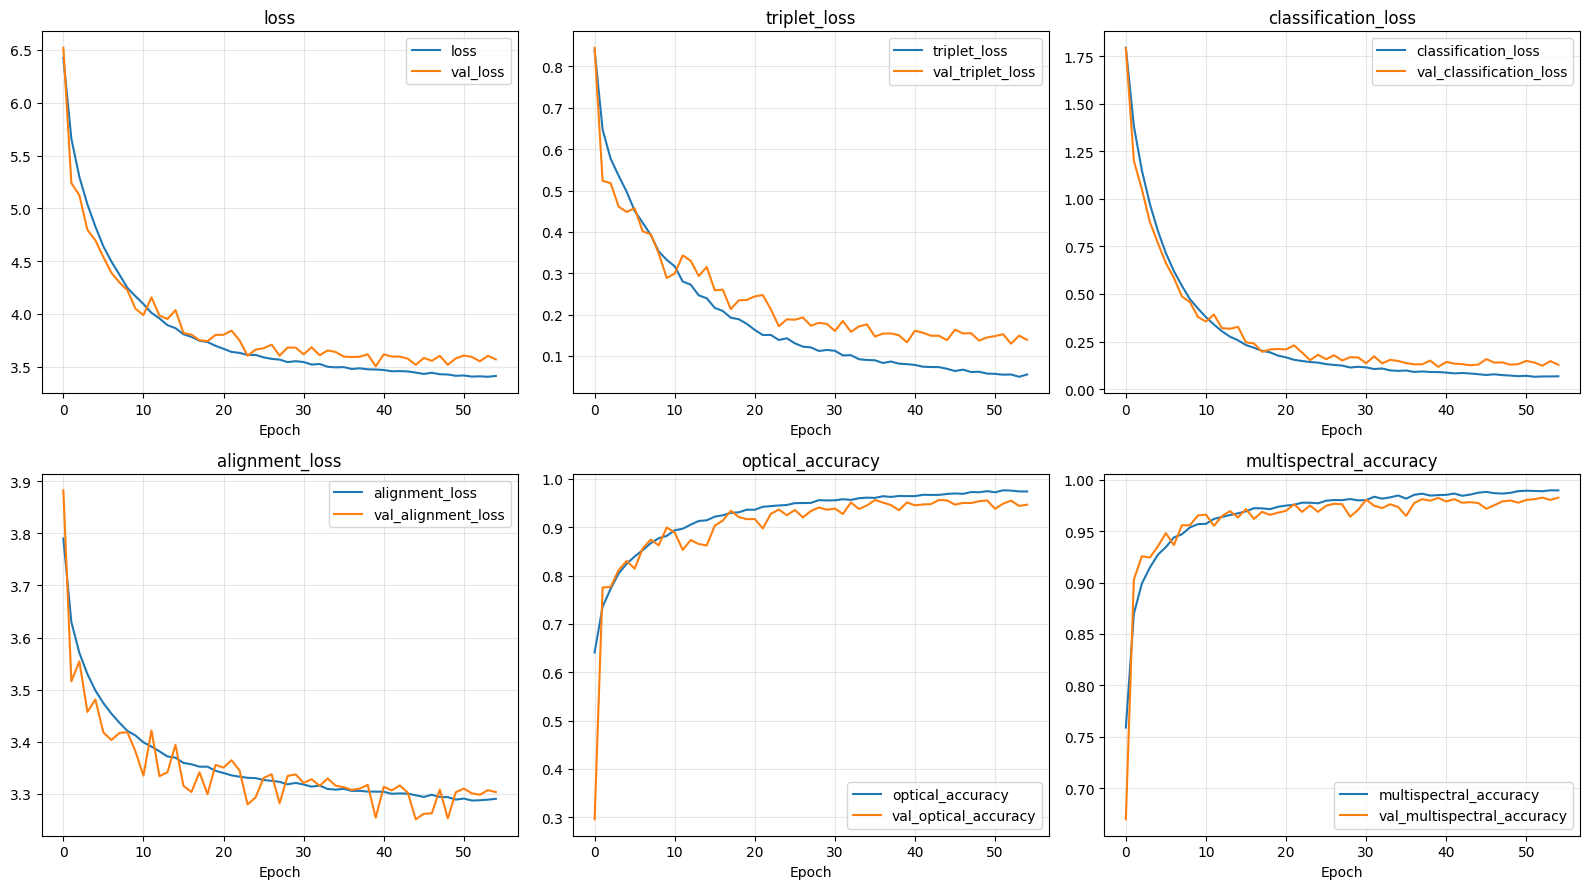

In [10]:
history_df = pd.DataFrame(history.history)

history_metrics = [
    "loss",
    "triplet_loss",
    "classification_loss",
    "alignment_loss",
    "optical_accuracy",
    "multispectral_accuracy",
]

figure, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for axis, metric in zip(axes, history_metrics):
    if metric in history_df:
        axis.plot(history_df[metric], label=metric)

    validation_metric = f"val_{metric}"

    if validation_metric in history_df:
        axis.plot(history_df[validation_metric], label=validation_metric)

    axis.set_title(metric)
    axis.set_xlabel("Epoch")
    axis.grid(True, alpha=0.3)
    axis.legend()

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "training_history_subplots.png",
    dpi=180,
)

plt.show()

## 6. Classification reports and embedding extraction

In [11]:
def predict_test(dataset):
    targets = []
    optical_predictions = []
    multispectral_predictions = []
    optical_embeddings = []
    multispectral_embeddings = []
    file_ids = []
    labels = []

    for inputs, batch_targets in tqdm(dataset, desc="Running test inference"):
        outputs = model(
            {
                "rgb": inputs["rgb"],
                "ms": inputs["ms"],
            },
            training=False,
        )

        targets.append(batch_targets.numpy())
        optical_predictions.append(np.argmax(outputs["optical_logits"].numpy(), axis=1))
        multispectral_predictions.append(np.argmax(outputs["multispectral_logits"].numpy(), axis=1))
        optical_embeddings.append(outputs["optical_embedding"].numpy())
        multispectral_embeddings.append(outputs["multispectral_embedding"].numpy())
        file_ids.append(inputs["file_id"].numpy())

        labels.extend(
            value.decode("utf-8")
            for value in inputs["label"].numpy()
        )

    return {
        "y": np.concatenate(targets),
        "optical_pred": np.concatenate(optical_predictions),
        "multispectral_pred": np.concatenate(multispectral_predictions),
        "optical_emb": np.concatenate(optical_embeddings),
        "multispectral_emb": np.concatenate(multispectral_embeddings),
        "file_id": np.concatenate(file_ids),
        "label": np.asarray(labels),
    }


pred = predict_test(test_metadata_ds)

optical_report = pd.DataFrame(
    classification_report(
        pred["y"],
        pred["optical_pred"],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
).T.reset_index(names="class")

multispectral_report = pd.DataFrame(
    classification_report(
        pred["y"],
        pred["multispectral_pred"],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
).T.reset_index(names="class")

optical_report["modality"] = "Optical"
multispectral_report["modality"] = "Multispectral"

classification_report_df = pd.concat(
    [optical_report, multispectral_report],
    ignore_index=True,
)

classification_report_df.to_csv(
    REPORT_DIR / "classification_reports_optical_multispectral.csv",
    index=False,
)

display(classification_report_df)

Running test inference: 0it [00:00, ?it/s]

,class,precision,recall,f1-score,support,modality
0,AnnualCrop,0.948357,0.897778,0.922374,450.000000,Optical
1,Forest,0.993258,0.982222,0.987709,450.000000,Optical
2,HerbaceousVegetation,0.929825,0.942222,0.935982,450.000000,Optical
3,Highway,0.972900,0.957333,0.965054,375.000000,Optical
4,Industrial,0.985955,0.936000,0.960328,375.000000,Optical
5,Pasture,0.923323,0.963333,0.942904,300.000000,Optical
6,PermanentCrop,0.889764,0.904000,0.896825,375.000000,Optical
7,Residential,0.929607,0.997778,0.962487,450.000000,Optical
8,River,0.974860,0.930667,0.952251,375.000000,Optical
9,SeaLake,0.971922,1.000000,0.985761,450.000000,Optical


## 7. Retrieval metrics for all four directions

In [12]:
def retrieval_metrics(query_embeddings, gallery_embeddings, query_labels, gallery_labels, direction, k_list=K_LIST, same_set=False):
    query_embeddings = query_embeddings / np.maximum(np.linalg.norm(query_embeddings, axis=1, keepdims=True), 1e-8)
    gallery_embeddings = gallery_embeddings / np.maximum(np.linalg.norm(gallery_embeddings, axis=1, keepdims=True), 1e-8)

    scores = query_embeddings @ gallery_embeddings.T

    if same_set:
        np.fill_diagonal(scores, -np.inf)

    ranking = np.argsort(-scores, axis=1)
    rows = []

    for k in k_list:
        precision_scores, recall_scores, f1_scores = [], [], []

        for query_index in range(len(query_embeddings)):
            retrieved_indices = ranking[query_index, :k]
            relevant = gallery_labels[retrieved_indices] == query_labels[query_index]

            correct = int(relevant.sum())
            total_relevant = int(np.sum(gallery_labels == query_labels[query_index])) - (1 if same_set else 0)

            precision = correct / k
            recall = correct / max(total_relevant, 1)
            f1 = 2.0 * precision * recall / max(precision + recall, 1e-12)

            precision_scores.append(precision)
            recall_scores.append(recall)
            f1_scores.append(f1)

        rows.append({
            "direction": direction,
            "k": k,
            "precision": np.mean(precision_scores),
            "recall": np.mean(recall_scores),
            "f1": np.mean(f1_scores),
        })

    return pd.DataFrame(rows), scores, ranking


tasks = {
    "Optical_to_Optical": (pred["optical_emb"], pred["optical_emb"], True),
    "Multispectral_to_Multispectral": (pred["multispectral_emb"], pred["multispectral_emb"], True),
    "Optical_to_Multispectral": (pred["optical_emb"], pred["multispectral_emb"], False),
    "Multispectral_to_Optical": (pred["multispectral_emb"], pred["optical_emb"], False),
}

metric_frames = []
retrieval_cache = {}

for direction, (query_embeddings, gallery_embeddings, same_set) in tasks.items():
    metrics_df, scores, ranking = retrieval_metrics(
        query_embeddings,
        gallery_embeddings,
        pred["label"],
        pred["label"],
        direction,
        K_LIST,
        same_set,
    )

    metric_frames.append(metrics_df)
    retrieval_cache[direction] = (scores, ranking)

retrieval_metrics_df = pd.concat(metric_frames, ignore_index=True)

retrieval_metrics_df.to_csv(
    REPORT_DIR / "retrieval_metrics_at_k.csv",
    index=False,
)

display(retrieval_metrics_df)

comparison_df = retrieval_metrics_df.pivot(
    index="direction",
    columns="k",
    values=["precision", "recall", "f1"],
)

display(comparison_df)

,direction,k,precision,recall,f1
0,Optical_to_Optical,1,0.951605,0.002353,0.004694
1,Optical_to_Optical,5,0.952148,0.011772,0.023252
2,Optical_to_Optical,10,0.950741,0.023509,0.045865
3,Optical_to_Optical,20,0.950025,0.046980,0.089464
4,Optical_to_Optical,50,0.949728,0.117405,0.208632
5,Multispectral_to_Multispectral,1,0.977778,0.002418,0.004825
6,Multispectral_to_Multispectral,5,0.978765,0.012100,0.023900
7,Multispectral_to_Multispectral,10,0.979852,0.024229,0.047269
8,Multispectral_to_Multispectral,20,0.980321,0.048479,0.092320
9,Multispectral_to_Multispectral,50,0.981630,0.121357,0.215655


precision                                \
k                                     1         5         10        20   
direction                                                                
Multispectral_to_Multispectral  0.977778  0.978765  0.979852  0.980321   
Multispectral_to_Optical        0.975556  0.976198  0.977136  0.978136   
Optical_to_Multispectral        0.946173  0.943012  0.944815  0.946049   
Optical_to_Optical              0.951605  0.952148  0.950741  0.950025   

                                            recall                      \
k                                     50        1         5         10   
direction                                                                
Multispectral_to_Multispectral  0.981630  0.002418  0.012100  0.024229   
Multispectral_to_Optical        0.979669  0.002406  0.012040  0.024102   
Optical_to_Multispectral        0.948943  0.002337  0.011637  0.023315   
Optical_to_Optical              0.949728  0.002353  0.011772  0.023509   

                                                          f1            \
k                                     20        50        1         5    
direction                                                                
Multispectral_to_Multispectral  0.048479  0.121357  0.004825  0.023900   
Multispectral_to_Optical        0.048253  0.120821  0.004801  0.023782   
Optical_to_Multispectral        0.046684  0.117048  0.004663  0.022985   
Optical_to_Optical              0.046980  0.117405  0.004694  0.023252   

                                                              
k                                     10        20        50  
direction                                                     
Multispectral_to_Multispectral  0.047269  0.092320  0.215655  
Multispectral_to_Optical        0.047026  0.091900  0.214762  
Optical_to_Multispectral        0.045488  0.088909  0.208049  
Optical_to_Optical              0.045865  0.089464  0.208632

## 8. Random test retrieval plots

In [13]:
def grayscale_preview(multispectral):
    visible_mean = np.mean(multispectral[..., :3], axis=-1)
    finite = visible_mean[np.isfinite(visible_mean)]
    if finite.size == 0:
        return np.zeros_like(visible_mean, dtype=np.float32)
    minimum, maximum = np.percentile(finite, [2, 98])
    return np.clip((np.nan_to_num(visible_mean, nan=minimum) - minimum) / max(maximum - minimum, 1e-8), 0.0, 1.0)


def collect_test_images(indices):
    required_indices = {int(i) for i in indices}
    collected, offset = {}, 0

    for inputs, targets in test_metadata_ds:
        for batch_index in range(len(targets)):
            global_index = offset + batch_index
            if global_index in required_indices:
                collected[global_index] = {
                    "rgb": inputs["rgb"][batch_index].numpy(),
                    "ms": inputs["ms"][batch_index].numpy(),
                    "label": inputs["label"][batch_index].numpy().decode("utf-8"),
                }
        offset += len(targets)
        if len(collected) == len(required_indices):
            break

    missing = required_indices - collected.keys()
    if missing:
        raise ValueError(f"Missing test images: {sorted(missing)}")

    return collected

In [14]:
TASK_INFO = {
    "Optical_to_Optical": {
        "title": "Optical → Optical Retrieval",
        "query_mode": "optical",
        "gallery_mode": "optical",
        "query_name": "Optical",
        "gallery_name": "Optical",
    },
    "Multispectral_to_Multispectral": {
        "title": (
            "Multispectral → Multispectral Retrieval"
        ),
        "query_mode": "multispectral",
        "gallery_mode": "multispectral",
        "query_name": "Multispectral",
        "gallery_name": "Multispectral",
    },
    "Optical_to_Multispectral": {
        "title": (
            "Optical → Multispectral "
            "Cross-Modal Retrieval"
        ),
        "query_mode": "optical",
        "gallery_mode": "multispectral",
        "query_name": "Optical",
        "gallery_name": "Multispectral",
    },
    "Multispectral_to_Optical": {
        "title": (
            "Multispectral → Optical "
            "Cross-Modal Retrieval"
        ),
        "query_mode": "multispectral",
        "gallery_mode": "optical",
        "query_name": "Multispectral",
        "gallery_name": "Optical",
    },
}

In [15]:
def display_retrieval_image(axis, sample, mode):
    if mode == "multispectral": axis.imshow(grayscale_preview(sample["ms"]), cmap="gray", vmin=0, vmax=1)
    else: axis.imshow(sample["rgb"])
    axis.set_xticks([]); axis.set_yticks([])


def set_retrieval_border(axis, color, linewidth=4):
    axis.set_frame_on(True)
    for spine in axis.spines.values(): spine.set_visible(True); spine.set_color(color); spine.set_linewidth(linewidth)


def plot_random_retrieval(direction, top_k=10, query_index=None):
    if direction not in TASK_INFO: raise ValueError(f"Unsupported retrieval direction: {direction}")
    if top_k > 10: raise ValueError("top_k must be 10 or lower for the three-row layout.")

    task = TASK_INFO[direction]
    scores, ranking = retrieval_cache[direction]
    if query_index is None: query_index = np.random.randint(len(pred["y"]))

    gallery_indices = ranking[query_index, :top_k]
    images = collect_test_images([query_index, *gallery_indices.tolist()])
    query = images[query_index]

    columns, total_rows = 5, 3
    figure, axes = plt.subplots(total_rows, columns, figsize=(15, 10))
    for axis in axes.flat: axis.axis("off")

    figure.suptitle(task["title"], fontsize=18, fontweight="bold", y=0.98)

    query_axis = axes[0, columns // 2]
    display_retrieval_image(query_axis, query, task["query_mode"])
    query_axis.axis("on"); query_axis.set_xticks([]); query_axis.set_yticks([])
    set_retrieval_border(query_axis, "blue", 5)
    query_axis.set_title(f"Query: {task['query_name']}\nClass: {query['label']}", fontsize=12, fontweight="bold", color="blue")

    rows = []
    for rank_position, gallery_index in enumerate(gallery_indices, start=1):
        plot_row, plot_column = (rank_position - 1) // columns + 1, (rank_position - 1) % columns
        axis = axes[plot_row, plot_column]
        gallery_index = int(gallery_index)
        gallery = images[gallery_index]

        display_retrieval_image(axis, gallery, task["gallery_mode"])
        axis.axis("on"); axis.set_xticks([]); axis.set_yticks([])

        relevant = int(gallery["label"] == query["label"])
        border_color = "green" if relevant else "red"
        result_text = "Correct" if relevant else "Wrong"

        set_retrieval_border(axis, border_color, 4)
        score = float(scores[query_index, gallery_index])

        axis.set_title(
            f"Rank {rank_position}: {task['gallery_name']}\n{gallery['label']} | {result_text}\nScore: {score:.3f}",
            fontsize=9, color=border_color, fontweight="bold"
        )

        rows.append({
            "direction": direction,
            "task": task["title"],
            "query_index": query_index,
            "query_modality": task["query_name"],
            "gallery_modality": task["gallery_name"],
            "rank": rank_position,
            "gallery_index": gallery_index,
            "query_label": query["label"],
            "gallery_label": gallery["label"],
            "score": score,
            "relevant": relevant,
            "result": result_text,
        })

    figure.text(0.5, 0.02, "Blue: Query     Green: Correct match     Red: Wrong match", ha="center", fontsize=11, fontweight="bold")
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(PLOT_DIR / f"{direction}_query_{query_index}_top_{top_k}.png", dpi=180, bbox_inches="tight")
    plt.show()

    return pd.DataFrame(rows)

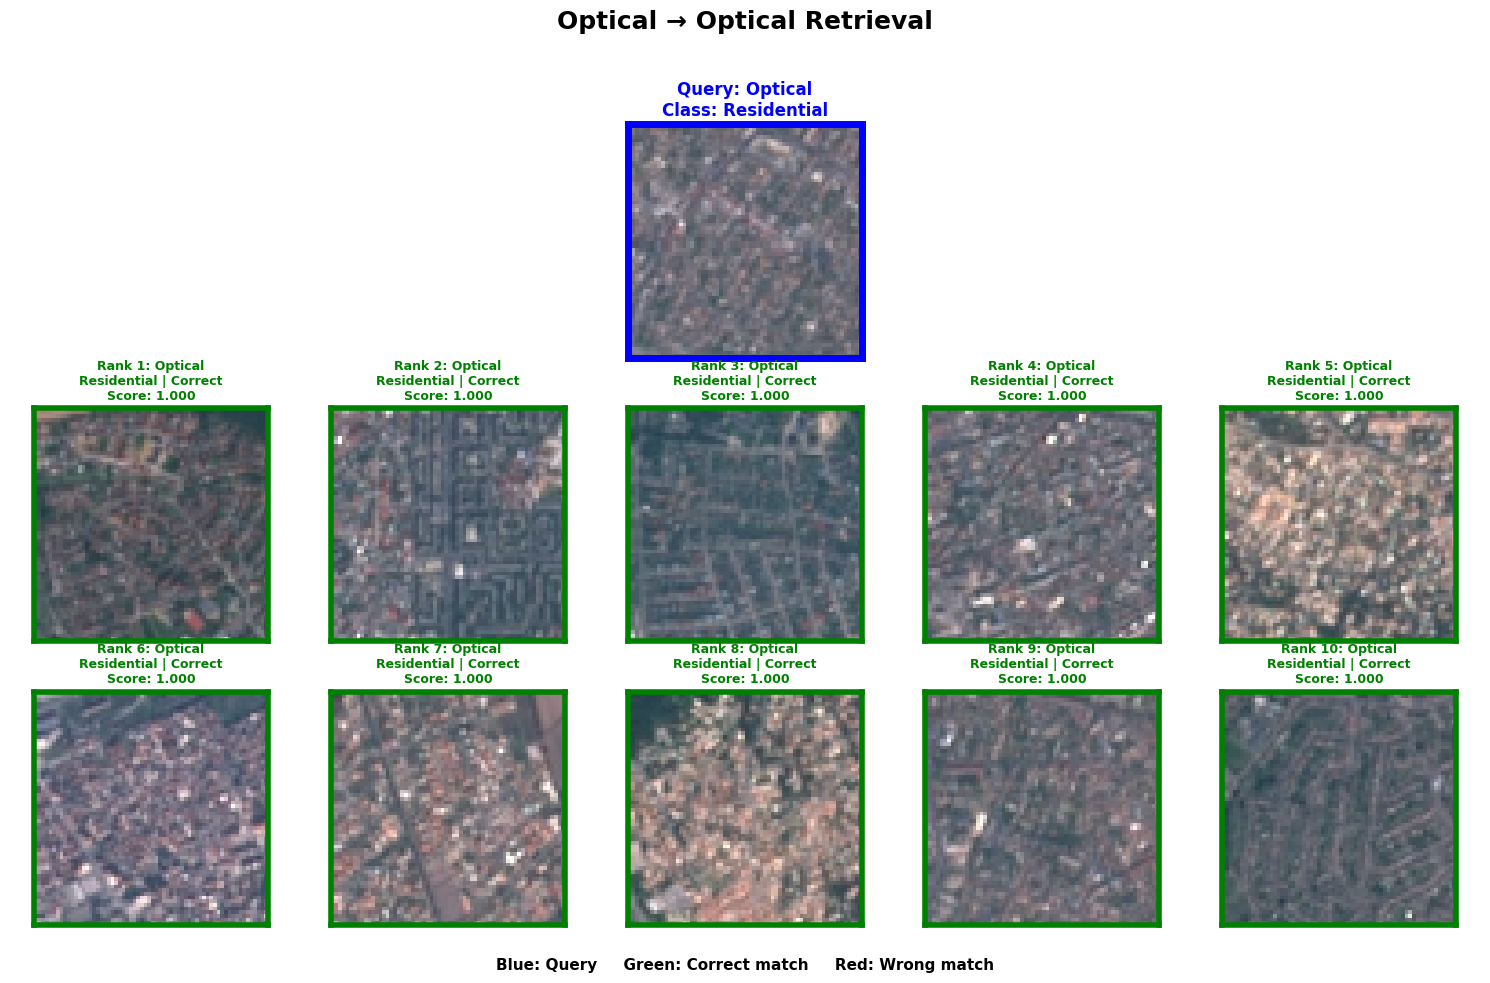

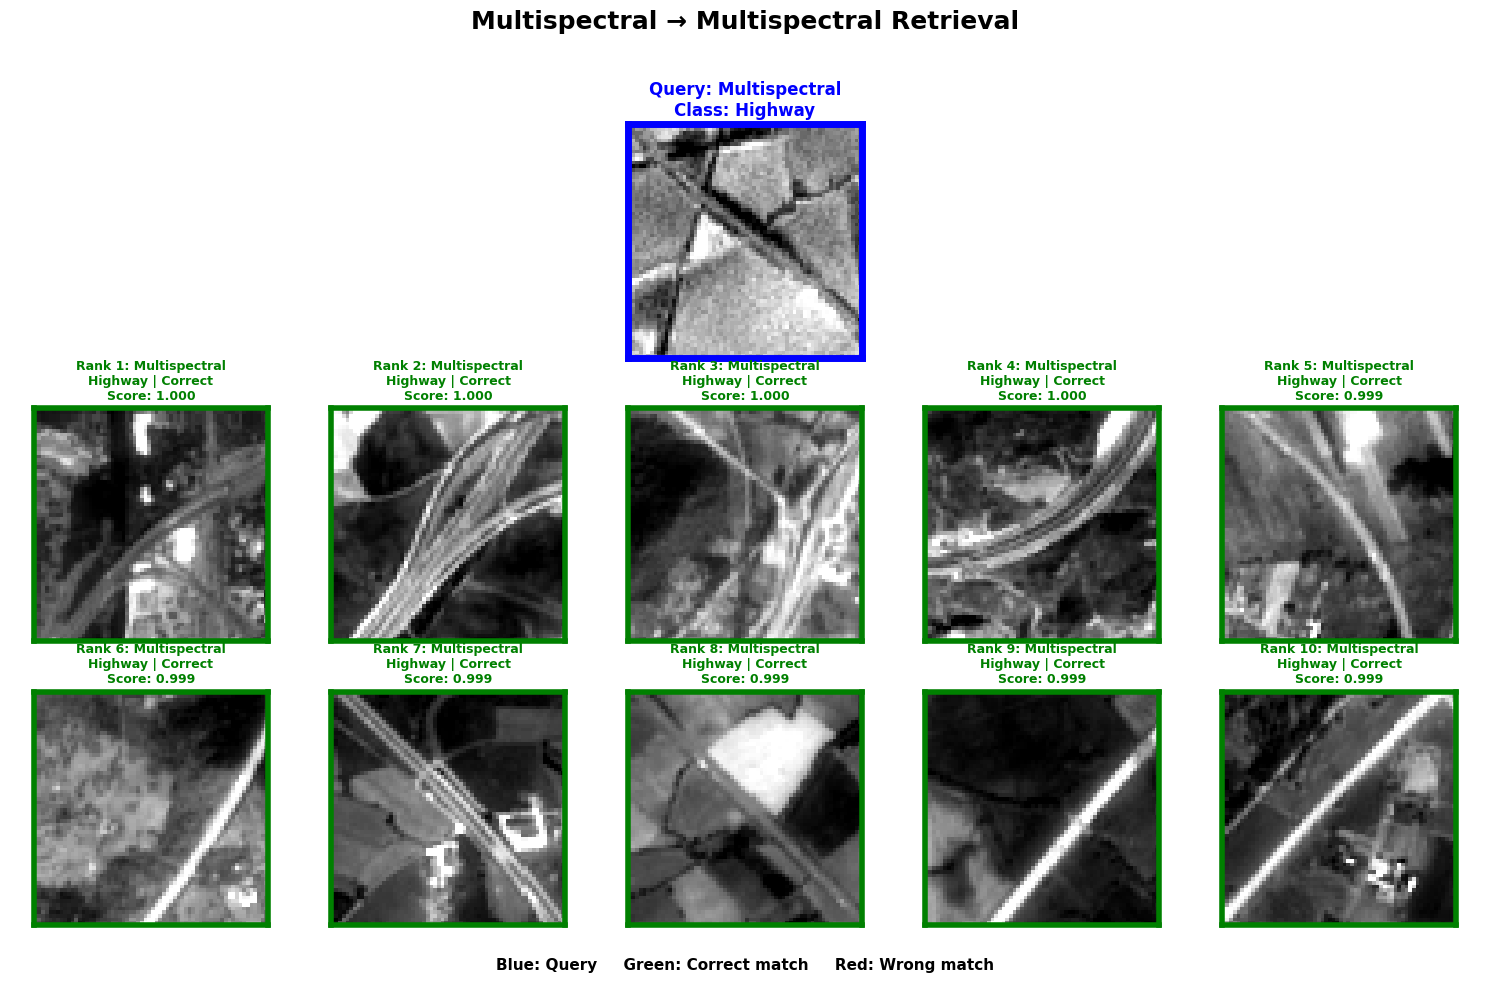

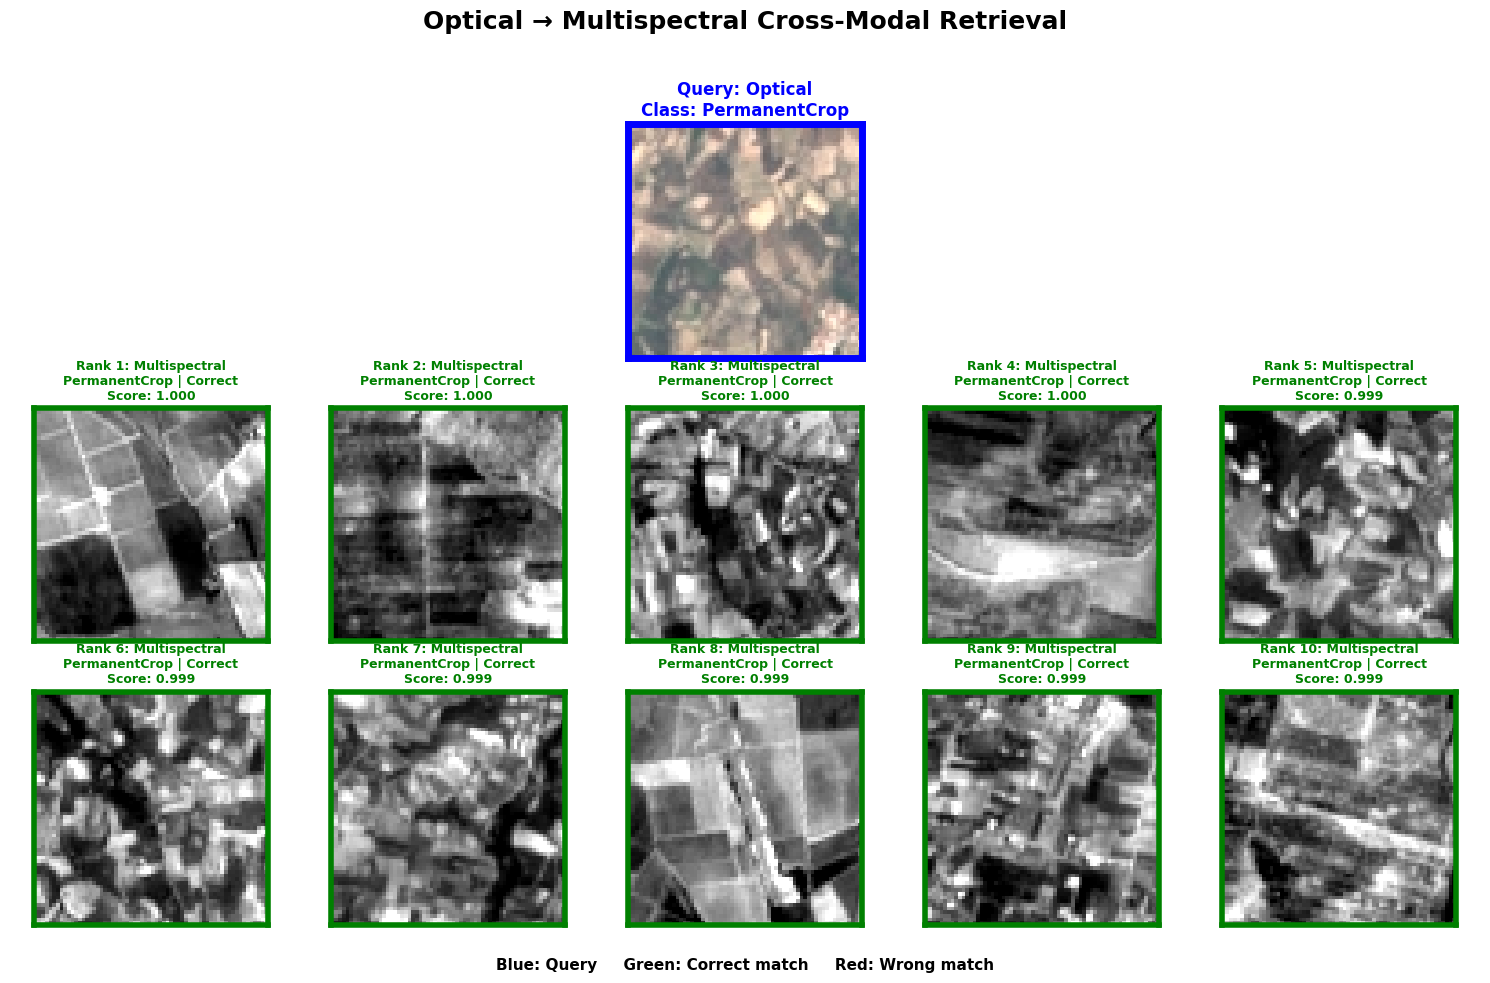

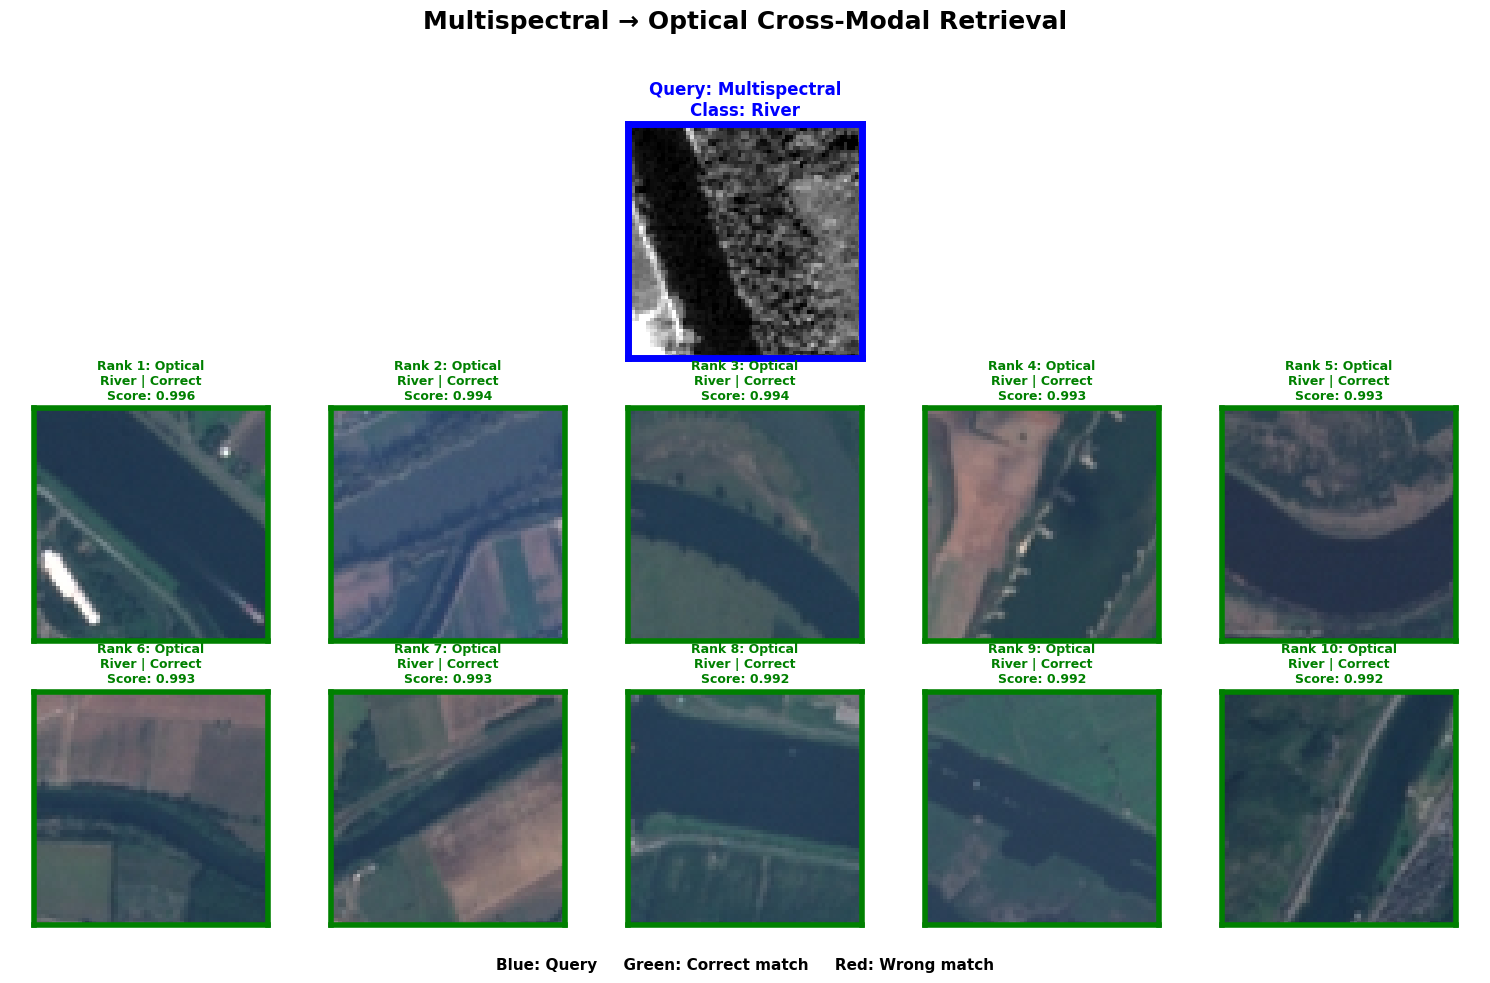

,direction,task,query_index,query_modality,gallery_modality,rank,gallery_index,query_label,gallery_label,score,relevant,result
0,Optical_to_Optical,Optical → Optical Retrieval,3174,Optical,Optical,1,1196,Residential,Residential,0.999992,1,Correct
1,Optical_to_Optical,Optical → Optical Retrieval,3174,Optical,Optical,2,1709,Residential,Residential,0.999974,1,Correct
2,Optical_to_Optical,Optical → Optical Retrieval,3174,Optical,Optical,3,3364,Residential,Residential,0.999974,1,Correct
3,Optical_to_Optical,Optical → Optical Retrieval,3174,Optical,Optical,4,516,Residential,Residential,0.999973,1,Correct
4,Optical_to_Optical,Optical → Optical Retrieval,3174,Optical,Optical,5,354,Residential,Residential,0.999969,1,Correct
5,Optical_to_Optical,Optical → Optical Retrieval,3174,Optical,Optical,6,3727,Residential,Residential,0.999964,1,Correct
6,Optical_to_Optical,Optical → Optical Retrieval,3174,Optical,Optical,7,3099,Residential,Residential,0.999963,1,Correct
7,Optical_to_Optical,Optical → Optical Retrieval,3174,Optical,Optical,8,931,Residential,Residential,0.999962,1,Correct
8,Optical_to_Optical,Optical → Optical Retrieval,3174,Optical,Optical,9,3635,Residential,Residential,0.999961,1,Correct
9,Optical_to_Optical,Optical → Optical Retrieval,3174,Optical,Optical,10,406,Residential,Residential,0.999961,1,Correct


In [16]:
sample_frames = []

for direction in [
    "Optical_to_Optical",
    "Multispectral_to_Multispectral",
    "Optical_to_Multispectral",
    "Multispectral_to_Optical",
]:
    result_df = plot_random_retrieval(
        direction=direction,
        top_k=10,
    )

    sample_frames.append(
        result_df
    )

sample_results = pd.concat(
    sample_frames,
    ignore_index=True,
)

sample_results.to_csv(
    REPORT_DIR
    / "random_retrieval_samples.csv",
    index=False,
)

display(
    sample_results
)

## 9. Save inference-ready artifacts

In [17]:
np.save(EMB_DIR / "test_optical_embeddings.npy", pred["optical_emb"])
np.save(EMB_DIR / "test_multispectral_embeddings.npy", pred["multispectral_emb"])
np.save(EMB_DIR / "test_targets.npy", pred["y"])
np.save(EMB_DIR / "test_file_ids.npy", pred["file_id"])

test_df.to_csv(REPORT_DIR / "test_metadata.csv", index=False)

config = {
    "image_size": IMAGE_SIZE,
    "rgb_channels": RGB_CHANNELS,
    "multispectral_channels": MS_CHANNELS,
    "multispectral_mean": MS_MEAN.tolist(),
    "multispectral_std": MS_STD.tolist(),
    "embedding_dim": EMBED_DIM,
    "class_names": CLASS_NAMES,
    "k_list": K_LIST,
}

(OUT_DIR / "inference_config.json").write_text(
    json.dumps(config, indent=2)
)

summary = {
    "model": "Hybrid APMSA Balanced Attention",
    "tasks": list(tasks),
    "classification_report": "reports/classification_reports_optical_multispectral.csv",
    "retrieval_metrics": "reports/retrieval_metrics_at_k.csv",
    "optical_encoder": "models/optical_encoder.keras",
    "multispectral_encoder": "models/multispectral_encoder.keras",
}

(OUT_DIR / "run_summary.json").write_text(
    json.dumps(summary, indent=2)
)

print("Saved inference artifacts to", OUT_DIR)

Saved inference artifacts to /kaggle/working/eurodata_optical_multispectral_hybrid_results


## 10. Upload result directory to Kaggle

In [18]:
user_secrets = UserSecretsClient()

os.environ["KAGGLE_USERNAME"] = user_secrets.get_secret("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = user_secrets.get_secret("KAGGLE_KEY")

kaggle_username = os.environ["KAGGLE_USERNAME"].strip()

RESULT_HANDLE = (
    f"{kaggle_username}/"
    "eurosat-optical-ms-hybrid-retrieval-results"
)

kagglehub.dataset_upload(
    RESULT_HANDLE,
    OUT_DIR,
    ignore_patterns=["*.tmp", "*.log"],
)

print("Uploaded:", RESULT_HANDLE)

Uploading Dataset https://kaggle.com/datasets/glitchr/eurosat-optical-ms-hybrid-retrieval-results ...
Starting upload for file /kaggle/working/eurodata_optical_multispectral_hybrid_results/run_summary.json


Uploading: 100%|██████████| 459/459 [00:00<00:00, 687B/s]

Upload successful: /kaggle/working/eurodata_optical_multispectral_hybrid_results/run_summary.json (459B)
Starting upload for file /kaggle/working/eurodata_optical_multispectral_hybrid_results/inference_config.json



Uploading: 100%|██████████| 1.01k/1.01k [00:00<00:00, 1.53kB/s]

Upload successful: /kaggle/working/eurodata_optical_multispectral_hybrid_results/inference_config.json (1008B)
Starting upload for file /kaggle/working/eurodata_optical_multispectral_hybrid_results/models/best.weights.h5


...


Uploading: 100%|██████████| 4.15M/4.15M [00:00<00:00, 5.28MB/s]

Upload successful: /kaggle/working/eurodata_optical_multispectral_hybrid_results/embeddings/test_optical_embeddings.npy (4MB)
Starting upload for file /kaggle/working/eurodata_optical_multispectral_hybrid_results/embeddings/test_targets.npy



Uploading: 100%|██████████| 16.3k/16.3k [00:00<00:00, 24.2kB/s]

Upload successful: /kaggle/working/eurodata_optical_multispectral_hybrid_results/embeddings/test_targets.npy (16KB)


Your dataset version has been created.
Files are being processed...
See at: https://kaggle.com/datasets/glitchr/eurosat-optical-ms-hybrid-retrieval-results
Uploaded: glitchr/eurosat-optical-ms-hybrid-retrieval-results
